# Load mesh and compute SDF

In [1]:
import open3d as o3d

print(o3d.__version__)

# Load the mesh using the legacy API
mesh_legacy = o3d.io.read_triangle_mesh("data/armadillo_bin.ply")

# Convert the mesh to the new Tensor API format
mesh = o3d.t.geometry.TriangleMesh.from_legacy(mesh_legacy)

# Create a RaycastingScene
scene = o3d.t.geometry.RaycastingScene()

# Cast triangle indices to UInt32
triangle_indices_uint32 = mesh.triangle['indices'].to(o3d.core.Dtype.UInt32)

# Add the mesh to the scene
scene.add_triangles(mesh.vertex['positions'], triangle_indices_uint32)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
0.17.0


0

# Render the SDF

In [2]:
import numpy as np

# Assuming `scene` is your RaycastingScene with the mesh already added

# Define the 3D grid
x = np.linspace(-1, 1, 100)
y = np.linspace(-1, 1, 100)
z = np.linspace(-1, 1, 100)

# Create a meshgrid and reshape it into a 2D array of points
xx, yy, zz = np.meshgrid(x, y, z, indexing='ij')
points = np.vstack([xx.ravel(), yy.ravel(), zz.ravel()]).T

# Convert to Open3D tensor
points_tensor = o3d.core.Tensor(points, dtype=o3d.core.Dtype.Float32)

# Compute SDF for all points
sdf_values_tensor = scene.compute_signed_distance(points_tensor)

Shape: (100, 100, 100)
Data Type: float32


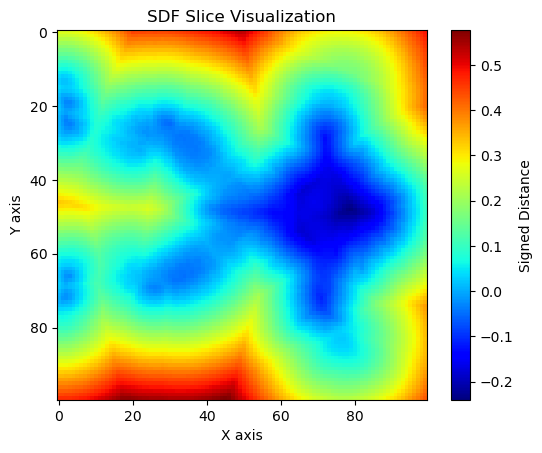

In [3]:
import matplotlib.pyplot as plt

# Convert the result to numpy and reshape to the original grid shape
# We'll use np.asarray and specify the data type explicitly
sdf_values = np.asarray(sdf_values_tensor.cpu().numpy(), dtype=np.float32).reshape(len(x), len(y), len(z))

# Check the shape and data type
print("Shape:", sdf_values.shape)
print("Data Type:", sdf_values.dtype)

# Select a slice for visualization
z_slice = sdf_values[:, :, len(z) // 2]

# Handle potential NaN or Inf values
z_slice = np.nan_to_num(z_slice)

# Ensure z_slice is of correct data type
z_slice = np.array(z_slice, dtype=np.float32)

# Plotting
plt.imshow(z_slice, cmap='jet', interpolation='nearest')
plt.colorbar(label='Signed Distance')
plt.title('SDF Slice Visualization')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.show()

# Calculate the distances using the neural SDF (256x3)

net_size=[256, 256, 256, 256]
num_layers=4


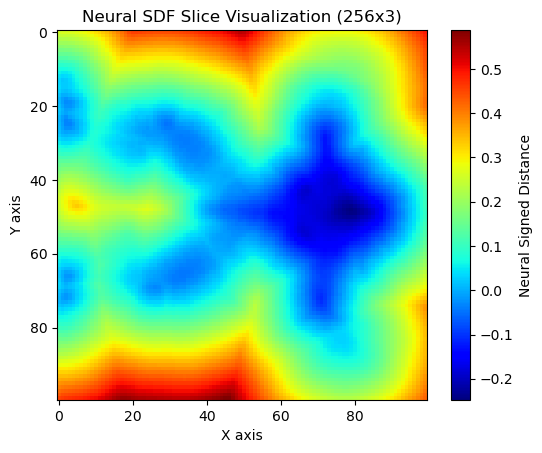

In [4]:
import torch
from util import from_pth

model_256x3 = from_pth('data/armadillo_256x3.pth', w0=30)

# Assuming `points` is your grid of points from the previous step
# Convert the numpy points to a PyTorch tensor
points_tensor = torch.tensor(points, dtype=torch.float32)

# If your model expects a batch dimension, add it
points_tensor = points_tensor.unsqueeze(0)

# Move the tensor to the same device as the model
device = next(model_256x3.parameters()).device
points_tensor = points_tensor.to(device)

# Prepare the input in the expected dictionary format
model_input = {"coords": points_tensor}

# Compute SDF values using the model
with torch.no_grad():
    model_output_256x3 = model_256x3(model_input)['model_out']

# Process the output (e.g., remove batch dimension, move to CPU)
sdf_values_neural_256x3 = model_output_256x3.squeeze(0).cpu().numpy()

# Reshape the output to the grid shape
sdf_values_neural_256x3 = sdf_values_neural_256x3.reshape(len(x), len(y), len(z))

# Visualization (using a slice)
z_slice_neural_256x3 = sdf_values_neural_256x3[:, :, len(z) // 2]
z_slice_neural_256x3 = np.nan_to_num(z_slice_neural_256x3)
plt.imshow(z_slice_neural_256x3, cmap='jet', interpolation='nearest')
plt.colorbar(label='Neural Signed Distance')
plt.title('Neural SDF Slice Visualization (256x3)')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.show()

In [5]:
# Calculate the difference between the two SDFs
difference = sdf_values - sdf_values_neural_256x3

# Compute the absolute values of the differences
absolute_difference = np.abs(difference)

# Find the maximum value (infinity norm)
infinity_norm_256x3 = np.max(absolute_difference)

print("Infinity Norm of the Difference (256x3):", infinity_norm_256x3)

Infinity Norm of the Difference (256x3): 0.11414571


Calculate the distances using the neural SDF (64x1)

net_size=[64, 64]
num_layers=2


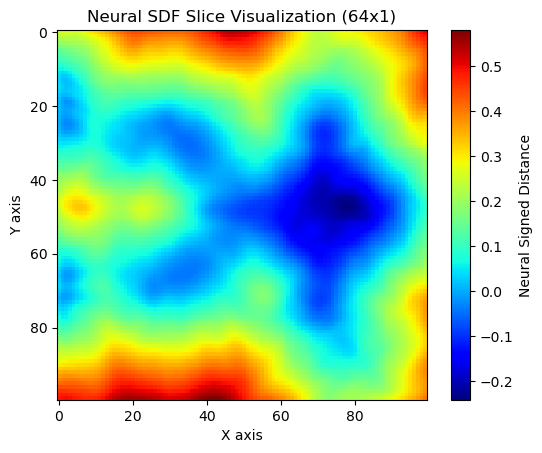

In [6]:
model_64x1 = from_pth('data/armadillo_64x1.pth', w0=30)

# Compute SDF values using the model
with torch.no_grad():
    model_output_64x1 = model_64x1(model_input)['model_out']

# Process the output (e.g., remove batch dimension, move to CPU)
sdf_values_neural_64x1 = model_output_64x1.squeeze(0).cpu().numpy()

# Reshape the output to the grid shape
sdf_values_neural_64x1 = sdf_values_neural_64x1.reshape(len(x), len(y), len(z))

# Visualization (using a slice)
z_slice_neural_64x1 = sdf_values_neural_64x1[:, :, len(z) // 2]
z_slice_neural_64x1 = np.nan_to_num(z_slice_neural_64x1)
plt.imshow(z_slice_neural_64x1, cmap='jet', interpolation='nearest')
plt.colorbar(label='Neural Signed Distance')
plt.title('Neural SDF Slice Visualization (64x1)')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.show()

In [8]:
# Calculate the difference between the two SDFs
difference = sdf_values - sdf_values_neural_64x1

# Compute the absolute values of the differences
absolute_difference = np.abs(difference)

# Find the maximum value (infinity norm)
infinity_norm_64x1 = np.max(absolute_difference)

print("Infinity Norm of the Difference (64x1):", infinity_norm_64x1)

Infinity Norm of the Difference (64x1): 0.1828404


# Delta calculation

In [9]:
delta = infinity_norm_64x1 + infinity_norm_256x3
delta

0.2969861